<a href="https://colab.research.google.com/github/bipasnadulal/ml-learn/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.6/615.6 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.6 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.18.1 which is incompatib

In [ ]:
!pip install scikit-learn

In [ ]:
#data
import numpy as np
import pandas as pd

#machine learning
import keras
from sklearn.datasets import fetch_california_housing

#visualization
import plotly.express as px

## Load Dataset

In [ ]:
california_housing_dataset = fetch_california_housing(as_frame = True)

housing_df = california_housing_dataset.frame

## Dataset exploration

In [ ]:
housing_df.shape

housing_df.head(100)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
95,2.0096,36.0,2.294016,1.066294,3469.0,1.493328,37.80,-122.26,1.300
96,2.8345,31.0,3.894915,1.127966,2048.0,1.735593,37.82,-122.26,1.838
97,2.0062,29.0,3.681319,1.175824,202.0,2.219780,37.81,-122.26,1.250
98,1.2185,22.0,2.945600,1.016000,2024.0,1.619200,37.82,-122.26,1.700


In [ ]:
housing_df.columns.to_list()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'] -> Features

['MedHouseVal'] -> Label, to predict

In [ ]:
housing_df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
housing_df.corr(numeric_only=True)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [ ]:
print('total number of rows:  {0}\n\n'.format(len(housing_df.index)))
housing_df.describe(include='all')

total number of rows:  20640




,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
px.scatter_matrix(housing_df, dimensions=['MedHouseVal', 'MedInc', 'HouseAge', 'AveRooms'])

In [ ]:
def create_model(learning_rate, input_features):
  inputs = {name : keras.Input(shape=(1,), name=name) for name in input_features}

  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))

  outputs = keras.layers.Dense(units=1)(concatenated_inputs)

  model = keras.Model(inputs=inputs, outputs=outputs)

  model.compile(
      optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate),
      loss = 'mean_squared_error',
      metrics = [keras.metrics.RootMeanSquaredError()]
  )

  return model

def train_model(model, dataset, input_features, label_name, batch_size, epochs):
  features = {name: dataset[name].values for name in input_features}
  label = dataset[label_name].values
  history = model.fit(x=features, y=label, batch_size = batch_size, epochs=epochs)

  return history

print("Successfully functions are defined")



Successfully functions are defined


In [ ]:
#Training the model with one feature
learning_rate = 0.001
epochs = 20
batch_size = 50


input_features = ["MedInc"]

model1 = create_model(
    learning_rate=learning_rate,
    input_features=input_features
)


history1 = train_model(
    model=model1,
    dataset=housing_df,
    input_features=input_features,
    label_name="MedHouseVal",
    batch_size=batch_size,
    epochs=epochs
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 57.5677 - root_mean_squared_error: 7.5833
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 31.3830 - root_mean_squared_error: 5.5938
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.6880 - root_mean_squared_error: 3.5496
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7873 - root_mean_squared_error: 1.6584
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8819 - root_mean_squared_error: 0.9390
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8054 - root_mean_squared_error: 0.8970
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7376 - root_mean_squared_error: 0.8588
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7161 - root_mean_squared_error: 0.8461
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7025 - root_mean_squared_error: 0.8379
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6999 - root_mean_squared_

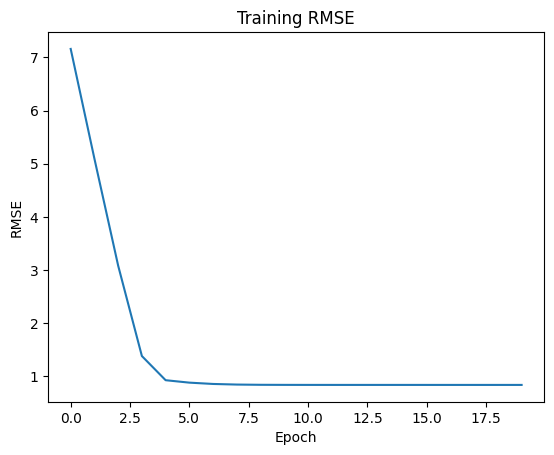

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history1.history["root_mean_squared_error"])
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training RMSE")
plt.show()



645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


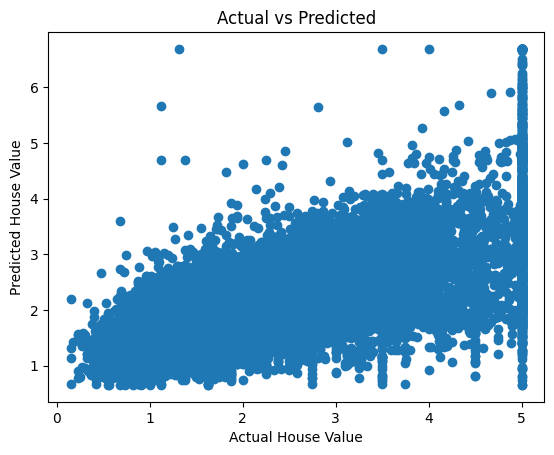

In [ ]:
features = {name: housing_df[name].values for name in input_features}

predictions = model1.predict(features)

plt.scatter(housing_df["MedHouseVal"], predictions)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
#Training the model with 3 feature
learning_rate = 0.001
epochs = 20
batch_size = 50


input_features = ["MedInc", 'HouseAge', 'AveRooms']

model2 = create_model(
    learning_rate=learning_rate,
    input_features=input_features
)


history2 = train_model(
    model=model2,
    dataset=housing_df,
    input_features=input_features,
    label_name="MedHouseVal",
    batch_size=batch_size,
    epochs=epochs
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1279 - root_mean_squared_error: 3.3955
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3179 - root_mean_squared_error: 1.1457
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7253 - root_mean_squared_error: 0.8515
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6665 - root_mean_squared_error: 0.8163
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6557 - root_mean_squared_error: 0.8096
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6661 - root_mean_squared_error: 0.8161
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6514 - root_mean_squared_error: 0.8069
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6778 - root_mean_squared_error: 0.8230
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6585 - root_mean_squared_error: 0.8114
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6618 - root_mean_squared_er

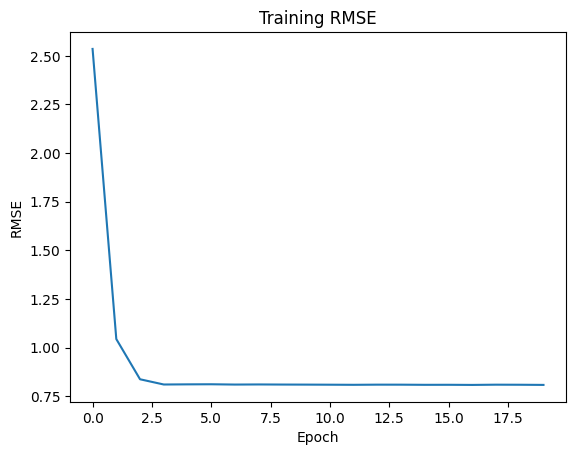

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history2.history["root_mean_squared_error"])
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training RMSE")
plt.show()

In [ ]:
#Training the model with 3 feature
learning_rate = 0.001
epochs = 20
batch_size = 50


input_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

model3 = create_model(
    learning_rate=learning_rate,
    input_features=input_features
)


history3= train_model(
    model=model3,
    dataset=housing_df,
    input_features=input_features,
    label_name="MedHouseVal",
    batch_size=batch_size,
    epochs=epochs
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1105395.7500 - root_mean_squared_error: 1045.0977
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 109790.4375 - root_mean_squared_error: 325.0009
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7611.2983 - root_mean_squared_error: 87.0109
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1429.1217 - root_mean_squared_error: 37.3612
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1415 - root_mean_squared_error: 3.4743
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.4466 - root_mean_squared_error: 2.7196
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.3592 - root_mean_squared_error: 2.0863
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.1977 - root_mean_squared_error: 1.7855
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0056 - root_mean_squared_error: 1.7195
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.412

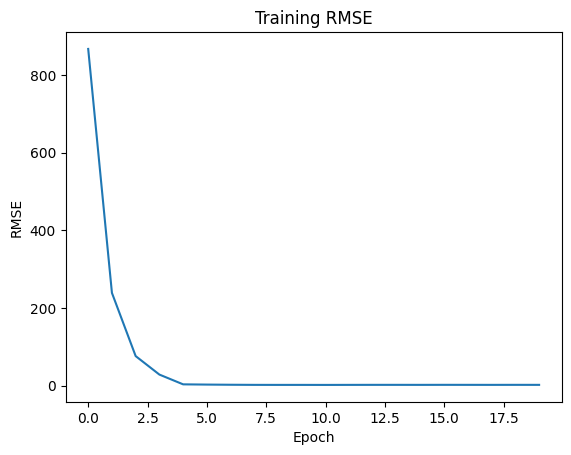

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history3.history["root_mean_squared_error"])
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training RMSE")
plt.show()

In [ ]:
input_features1 = ["MedInc"]
input_features2 = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

test_features1 = {
    name: housing_df[name].values
    for name in input_features1
}

test_features2 = {
    name: housing_df[name].values
    for name in input_features2
}

y_test = housing_df["MedHouseVal"].values

loss1, rmse1 = model1.evaluate(
    test_features1,
    y_test,
    verbose=0
)

loss2, rmse2 = model3.evaluate(
    test_features2,
    y_test,
    verbose=0
)



comparison = pd.DataFrame({
    "Model": [
        "Model 1 (MedInc)",
        "Model 3 (MedInc + HouseAge + AveRooms + AveBedrms + Population + AveOccup + Latitude + Longitude)"
    ],
    "Loss (MSE)": [
        loss1,
        loss2
    ],
    "RMSE": [
        rmse1,
        rmse2
    ]
})

print(comparison)

                                               Model  Loss (MSE)      RMSE
0                                   Model 1 (MedInc)    0.701315  0.837445
1  Model 3 (MedInc + HouseAge + AveRooms + AveBed...    2.617722  1.617938


In [ ]:
import pandas as pd
import numpy as np

def build_batch(df, batch_size):
    batch = df.sample(n=batch_size).copy()
    batch.reset_index(drop=True, inplace=True)
    return batch

def predict_house_prices(model, df, input_features, label_name, batch_size=10):
    # Random sample
    batch = build_batch(df, batch_size)

    # Features for prediction
    features = {
        name: batch[name].values
        for name in input_features
    }

    # Predict
    predictions = model.predict(features, verbose=0).flatten()

    # Create output table
    output = batch[input_features].copy()
    output["Actual Price"] = batch[label_name].values
    output["Predicted Price"] = predictions
    output["Absolute Error"] = np.abs(
        output["Actual Price"] - output["Predicted Price"]
    )

    return output

In [ ]:
predictions = predict_house_prices(
    model=model2,
    df=housing_df,
    input_features=input_features2,
    label_name="MedHouseVal",
    batch_size=10
)

print(predictions)

   MedInc  HouseAge   AveRooms  ...  Actual Price  Predicted Price  Absolute Error
0  3.5547      31.0   5.552239  ...         2.000         2.673115        0.673115
1  3.4600      32.0   6.884314  ...         1.239         3.192730        1.953730
2  5.2951      12.0   7.550000  ...         3.862         3.491683        0.370317
3  6.5764      17.0   6.555118  ...         3.490         3.051977        0.438023
4  2.9191      19.0   4.457386  ...         1.594         2.112154        0.518154
5  3.0469      16.0   5.764228  ...         0.722         2.691880        1.969880
6  5.2759      14.0   6.501438  ...         1.829         3.038836        1.209836
7  4.0750      28.0   5.815832  ...         2.379         2.720017        0.341017
8  3.4861      17.0  17.300000  ...         1.375         7.591352        6.216352
9  1.9387      30.0   3.655294  ...         1.417         1.766451        0.349451

[10 rows x 11 columns]


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:237: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: {'MedInc': 'MedInc', 'HouseAge': 'HouseAge', 'AveRooms': 'AveRooms'}
Received: inputs={'MedInc': 'Tensor(shape=(10,))', 'HouseAge': 'Tensor(shape=(10,))', 'AveRooms': 'Tensor(shape=(10,))', 'AveBedrms': 'Tensor(shape=(10,))', 'Population': 'Tensor(shape=(10,))', 'AveOccup': 'Tensor(shape=(10,))', 'Latitude': 'Tensor(shape=(10,))', 'Longitude': 'Tensor(shape=(10,))'}

